In [1]:
! pip install transformers[torch] datasets scikit-learn accelerate sentencepiece captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.6 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.2

In [2]:
import os
import json
import glob
import re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import multiprocessing
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding
)
from captum.attr import LayerIntegratedGradients

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
def clean_text_advanced(text):
    if not text: return ""
    text = text.replace('·', ' * ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def clean_question(q_text):
    if not q_text: return ""
    q_text = re.sub(r'^\d+[\s\.\-\,]+', '', q_text)
    return clean_text_advanced(q_text)

def load_and_flatten_jsonl(folder_path):
    all_questions, all_essays, all_labels = [], [], []
    search_pattern = os.path.join(folder_path, "*_essay_evaluated.jsonl")
    jsonl_files = glob.glob(search_pattern)
    print(f"Found {len(jsonl_files)} JSONL files matching '*_essay_evaluated.jsonl'")
    
    for file_path in jsonl_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line: continue
                try:
                    data = json.loads(line)
                    answer_variants = data.get("answer_variants", {})
                    variant_evaluations = data.get("variant_evaluations", {})
                    
                    for variant_name, evaluation_data in variant_evaluations.items():
                        essay_text = clean_text_advanced(answer_variants.get(variant_name, ""))
                        if not essay_text: continue
                            
                        evaluations = evaluation_data.get("evaluations", [])
                        for eval_item in evaluations:
                            question = clean_question(eval_item.get("question", ""))
                            satisfied = eval_item.get("satisfied", None)
                            if question and satisfied is not None:
                                all_questions.append(question)
                                all_essays.append(essay_text)
                                all_labels.append(1 if satisfied else 0)
                except Exception as e:
                    print(f"Error parsing line {line_num} in {os.path.basename(file_path)}: {e}")
                
    return pd.DataFrame({"question": all_questions, "essay_text": all_essays, "label": all_labels})

In [5]:
DATA_FOLDER_PATH = "/kaggle/input/datasets/adhamashraf202200953/technical-parsed-questions"
df = load_and_flatten_jsonl(DATA_FOLDER_PATH)

print(f"Shape before checking duplicates: {df.shape}")
df = df.drop_duplicates(subset=['question', 'essay_text'], keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['label'])

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=2,
    hidden_dropout_prob=0.2,       
    attention_probs_dropout_prob=0.2
)

model.float() 
model.to(device)

Found 4 JSONL files matching '*_essay_evaluated.jsonl'
Shape before checking duplicates: (154091, 3)
Shape after removing duplicates: (153881, 3)


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias       

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-5): 6 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.2, inplace=False)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNo

In [6]:
def preprocess_function(examples):
    return tokenizer(examples['question'], examples['essay_text'], truncation=True, max_length=512)

num_cores = multiprocessing.cpu_count()
tokenized_datasets = dataset.map(
    preprocess_function, 
    batched=True, 
    remove_columns=['question', 'essay_text'],
    num_proc=num_cores,
    load_from_cache_file=True
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

class AntiOverfittingTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average='binary'),
        "precision": precision_score(labels, preds, average='binary'),
        "recall": recall_score(labels, preds, average='binary')
    }

Map (num_proc=4):   0%|          | 0/123104 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/15388 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/15389 [00:00<?, ? examples/s]

In [7]:
training_args = TrainingArguments(
    output_dir="./deberta-essay-grader",       
    learning_rate=2e-5,                        
    per_device_train_batch_size=16,             
    per_device_eval_batch_size=16,
    num_train_epochs=2,                        
    weight_decay=0.02,                
    lr_scheduler_type="cosine",       
    warmup_ratio=0.1,                 
    eval_strategy="steps",               
    eval_steps=3000,                  
    save_strategy="steps",                     
    save_steps=3000,                      
    save_total_limit=2,               
    load_best_model_at_end=True,               
    metric_for_best_model="f1",                
    logging_steps=500,                         
    report_to="none",
    
    fp16=False,                         
    bf16=False                          
)

trainer = AntiOverfittingTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,  
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting Anti-Overfitting Training...")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Starting Anti-Overfitting Training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
3000,0.581911,0.577016,0.732454,0.712359,0.686230,0.740558
6000,0.550265,0.580992,0.736678,0.724766,0.680658,0.774985


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7694, training_loss=0.5756657696836237, metrics={'train_runtime': 3942.7878, 'train_samples_per_second': 62.445, 'train_steps_per_second': 1.951, 'total_flos': 1.2160600903565952e+16, 'train_loss': 0.5756657696836237, 'epoch': 2.0})

Generating Performance Tracking Plots...

--- Detailed Performance Logs ---
🔹 [Step   500] | Training Loss: 0.6632
🔹 [Step  1000] | Training Loss: 0.6221
🔹 [Step  1500] | Training Loss: 0.6074
🔹 [Step  2000] | Training Loss: 0.5947
🔹 [Step  2500] | Training Loss: 0.5787
🔹 [Step  3000] | Training Loss: 0.5819

[Step  3000] ---------- VALIDATION METRICS ----------
    ↳ Validation Loss : 0.5770
    ↳ Accuracy        : 0.7325
    ↳ F1-Score        : 0.7124
    ↳ Precision       : 0.6862
    ↳ Recall          : 0.7406
--------------------------------------------------

🔹 [Step  3500] | Training Loss: 0.5739
🔹 [Step  4000] | Training Loss: 0.5642
🔹 [Step  4500] | Training Loss: 0.5562
🔹 [Step  5000] | Training Loss: 0.5541
🔹 [Step  5500] | Training Loss: 0.5514
🔹 [Step  6000] | Training Loss: 0.5503

[Step  6000] ---------- VALIDATION METRICS ----------
    ↳ Validation Loss : 0.5810
    ↳ Accuracy        : 0.7367
    ↳ F1-Score        : 0.7248
    ↳ Precision       : 0.6807
    ↳ Recall   

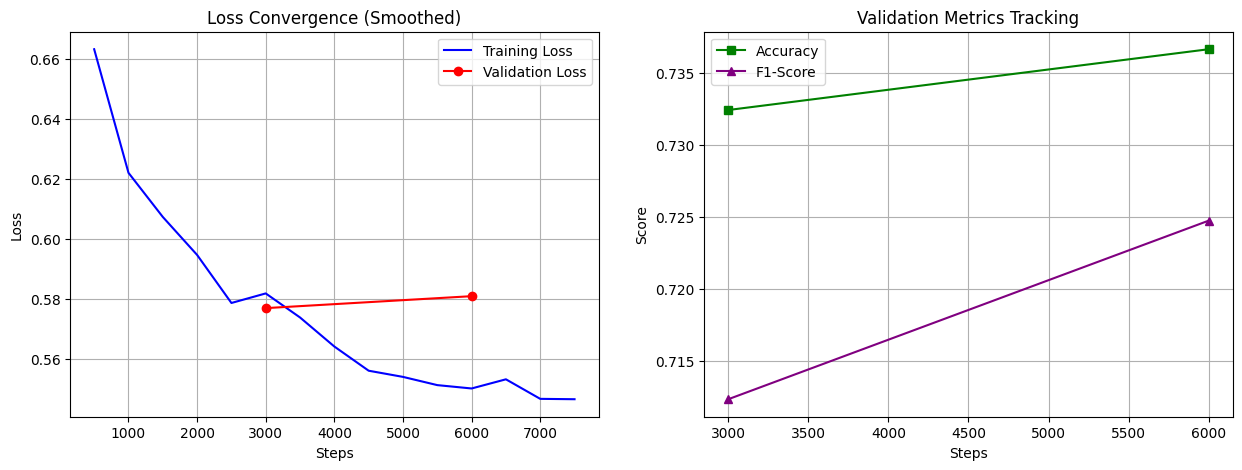

In [8]:
print("Generating Performance Tracking Plots...")
history = trainer.state.log_history
train_steps, train_loss = [], []
eval_steps, eval_loss, eval_accuracy, eval_f1 = [], [], [], []

print("\n--- Detailed Performance Logs ---")

for log in history:
    if 'loss' in log and 'eval_loss' not in log:
        step = log['step']
        loss_val = log['loss']
        train_steps.append(step)
        train_loss.append(loss_val)
        print(f"🔹 [Step {step:5d}] | Training Loss: {loss_val:.4f}")
        
    elif 'eval_loss' in log:
        step = log['step']
        e_loss = log['eval_loss']
        e_acc = log['eval_accuracy']
        e_f1 = log['eval_f1']
        
        eval_steps.append(step)
        eval_loss.append(e_loss)
        eval_accuracy.append(e_acc)
        eval_f1.append(e_f1)
        
        print(f"\n[Step {step:5d}] ---------- VALIDATION METRICS ----------")
        print(f"    ↳ Validation Loss : {e_loss:.4f}")
        print(f"    ↳ Accuracy        : {e_acc:.4f}")
        print(f"    ↳ F1-Score        : {e_f1:.4f}")
        if 'eval_precision' in log: print(f"    ↳ Precision       : {log['eval_precision']:.4f}")
        if 'eval_recall' in log:    print(f"    ↳ Recall          : {log['eval_recall']:.4f}")
        print("-" * 50 + "\n")

print("------------------------------------\n")

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label='Training Loss', color='blue')
if eval_steps: plt.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o')
plt.title('Loss Convergence (Smoothed)')
plt.xlabel('Steps'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
if eval_steps:
    plt.plot(eval_steps, eval_accuracy, label='Accuracy', color='green', marker='s')
    plt.plot(eval_steps, eval_f1, label='F1-Score', color='purple', marker='^')
plt.title('Validation Metrics Tracking')
plt.xlabel('Steps'); plt.ylabel('Score')
plt.legend(); plt.grid(True)
plt.savefig('./training_performance_metrics.png', dpi=300)
plt.show()

In [9]:
model.eval()

def forward_func(inputs_embeds, attention_mask):
    outputs = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
    return outputs.logits

# lig = LayerIntegratedGradients(forward_func, model.deberta.embeddings.word_embeddings)

# sample_xai = test_df.sample(1, random_state=42).iloc[0]
# xai_q = sample_xai['question']
# xai_e = sample_xai['essay_text']
# actual_label = sample_xai['label']

# print(f"Target Question: {xai_q}")
# print(f"Ground Truth Label: {actual_label}")

# inputs = tokenizer(xai_q, xai_e, return_tensors="pt", truncation=True, max_length=512).to(device)
# input_ids = inputs['input_ids']
# attention_mask = inputs['attention_mask']

# with torch.no_grad():
#     pred_logits = model(**inputs).logits
#     pred_class = torch.argmax(pred_logits, dim=1).item()
# print(f"Model Predicted Class: {pred_class}")

# attributions, delta = lig.attribute(
#     inputs=input_ids,
#     additional_forward_args=(attention_mask,),
#     target=pred_class,
#     return_convergence_delta=True
# )

# attributions = attributions.sum(dim=-1).squeeze(0).cpu().detach().numpy()
# tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())

# print("\n--- Token Importance Dashboard ---")
# for token, score in zip(tokens, attributions):
#     clean_token = token.replace(' ', ' ').replace(' ', ' ')
#     if score > 0.01:
#         print(f"\033[92m{clean_token}(+{score:.2f})\033[0m", end=" ")
#     elif score < -0.01:
#         print(f"\033[91m{clean_token}({score:.2f})\033[0m", end=" ")
#     else:
#         print(clean_token, end=" ")
# print("\n" + "="*50)

final_model_path = "./best_deberta_grader_model"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"Model and Tokenizer successfully saved to {final_model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer successfully saved to ./best_deberta_grader_model
